# Experiment 1 — Quantization Perplexity

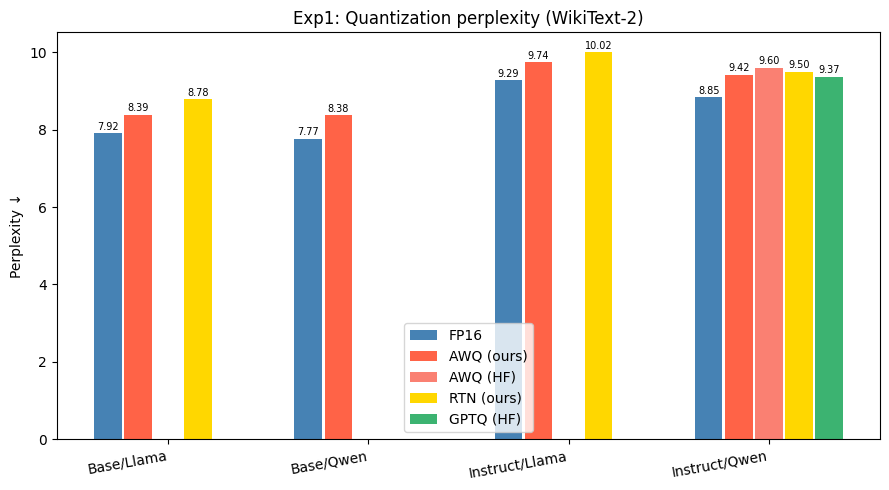

In [1]:
import json, re
import matplotlib.pyplot as plt
import numpy as np

exp1 = json.load(open("results/exp1.json"))

def _parse(e):
    ppl = e.get("perplexity", 9999)
    if ppl > 100:
        return None  # broken run
    src = e.get("model", "") or e.get("weight_path", "")
    family = "Qwen" if "Qwen" in src else "Llama"
    instruct = "Instruct" in src

    mode = e.get("mode")
    if mode is None:
        wp = e.get("weight_path", "")
        m  = e.get("model", "")
        if   "rtn"  in wp: mode = "rtn"
        elif "gptq" in wp: mode = "gptq"
        elif "awq"  in wp: mode = "awq"
        elif "AWQ"  in m:  mode = "awq_hf"
        elif "GPTQ" in m:  mode = "gptq_hf"
        else:              mode = "fp16"
    mode = {"awq_int4": "awq", "rtn_int4": "rtn"}.get(mode, mode)

    key = f"{'Instruct' if instruct else 'Base'}/{family}"
    return (key, mode, ppl)

# Keep best (lowest) PPL per (model-key, mode)
best = {}
for e in exp1:
    r = _parse(e)
    if r is None: continue
    k = (r[0], r[1])
    if k not in best or r[2] < best[k]:
        best[k] = r[2]

all_keys     = sorted(set(k for k, _ in best))
modes_order  = ["fp16", "awq", "awq_hf", "rtn", "gptq", "gptq_hf"]
mode_label   = {"fp16": "FP16", "awq": "AWQ (ours)", "awq_hf": "AWQ (HF)",
                "rtn": "RTN (ours)", "gptq": "GPTQ (ours)", "gptq_hf": "GPTQ (HF)"}
mode_color   = {"fp16": "steelblue", "awq": "tomato", "awq_hf": "salmon",
                "rtn": "gold", "gptq": "seagreen", "gptq_hf": "mediumseagreen"}

data    = {k: {m: best.get((k, m)) for m in modes_order} for k in all_keys}
present = [m for m in modes_order if any(data[k][m] for k in all_keys)]

x = np.arange(len(all_keys))
w = 0.75 / len(present)
fig, ax = plt.subplots(figsize=(9, 5))
for i, m in enumerate(present):
    vals   = [data[k][m] for k in all_keys]
    offset = (i - len(present) / 2 + 0.5) * w
    bars   = ax.bar(x + offset, [v or 0 for v in vals], w * 0.92,
                    label=mode_label[m], color=mode_color[m])
    for bar, v in zip(bars, vals):
        if v:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(all_keys, rotation=10, ha="right")
ax.set_ylabel("Perplexity ↓")
ax.set_title("Exp1: Quantization perplexity (WikiText-2)")
ax.legend()
plt.tight_layout()
plt.show()

# Experiment 2 — End-to-end Prefill / Decode

In [2]:
import json, pandas as pd
from IPython.display import display

exp2 = json.load(open("results/exp2.json"))
print(f"Device: {exp2['device']}\n")

for metric, label in [("decode_tok_per_s", "Decode tok/s"), ("prefill_tok_per_s", "Prefill tok/s")]:
    rows = {}
    for kernel, kd in exp2["e2e"].items():
        rows[kernel] = {e["batch_size"]: round(e[metric], 1) for e in kd["by_batch"]}
    if metric == "decode_tok_per_s" and "vllm_reference" in exp2:
        rows["vllm"] = {e["batch_size"]: round(e["decode_tok_per_s"], 1)
                        for e in exp2["vllm_reference"]["by_batch"]}
    df = pd.DataFrame(rows).T
    df.columns.name = "batch_size"
    df.index.name = "kernel"
    print(f"=== {label} ===")
    display(df)
    print()

vram = {k: f"{v['peak_vram_gb']:.1f} GB" for k, v in exp2["e2e"].items()}
print("Peak VRAM:", vram)

Device: NVIDIA A10

=== Decode tok/s ===


batch_size,1,4,16,32
kernel,,,,
triton,5.0,19.6,77.4,146.4
vanilla,1.7,6.8,27.0,53.5
marlin,31.6,124.4,484.9,974.9
fp16_baseline,27.5,106.7,382.0,677.7
vllm,79.3,315.6,1138.3,1867.8



=== Prefill tok/s ===


batch_size,1,4,16,32
kernel,,,,
triton,1244.5,1322.5,1243.6,1245.6
vanilla,463.5,665.3,754.3,806.3
marlin,3456.2,3299.8,3385.4,3277.3
fp16_baseline,3598.5,3821.8,4073.1,4019.2



Peak VRAM: {'triton': '11.8 GB', 'vanilla': '11.8 GB', 'marlin': '11.8 GB', 'fp16_baseline': '21.3 GB'}


# Experiment 3 — GSM8k / MMLU Accuracy

In [5]:
import json, pandas as pd
from IPython.display import display

exp3 = json.load(open("results/exp3.json"))

def _model_name(e):
    if "model" in e:
        return e["model"].split("/")[-1]
    return e["weight_path"].split("/")[-1].replace(".migrated.pt", "").replace(".pt", "")

def _score(r):
    s = 0
    if r["MMLU"]  != "—": s += float(r["MMLU"].rstrip("%"))
    if r["GSM8k"] != "—": s += float(r["GSM8k"].rstrip("%"))
    return s

rows = [{"model": _model_name(e),
         "GSM8k": f"{e['gsm8k']*100:.1f}%" if "gsm8k" in e else "—",
         "MMLU":  f"{e['mmlu']*100:.1f}%"  if "mmlu"  in e else "—",
         "VRAM":  f"{e['peak_vram_gb']:.1f} GB"} for e in exp3]

# Deduplicate: same model name → keep highest combined score
seen = {}
for r in rows:
    if r["model"] not in seen or _score(r) > _score(seen[r["model"]]):
        seen[r["model"]] = r
df = pd.DataFrame(seen.values()).set_index("model")

def _style(df):
    styled = df.style
    for col in ["GSM8k", "MMLU"]:
        nums = {i: float(v.rstrip("%")) for i, v in df[col].items() if v != "—"}
        if not nums: continue
        styled = styled.set_properties(
            subset=pd.IndexSlice[[max(nums, key=nums.get)], [col]],
            **{"font-weight": "bold", "background-color": "#e8f5e9"})
    return styled

display(_style(df))

,GSM8k,MMLU,VRAM
model,,,
Qwen2.5-7B-Instruct,—,55.0%,18.4 GB
awq_meta-llama_Llama-3.1-8B-Instruct,69.4%,66.2%,21.6 GB


# Experiment 4 — GEMM Roofline

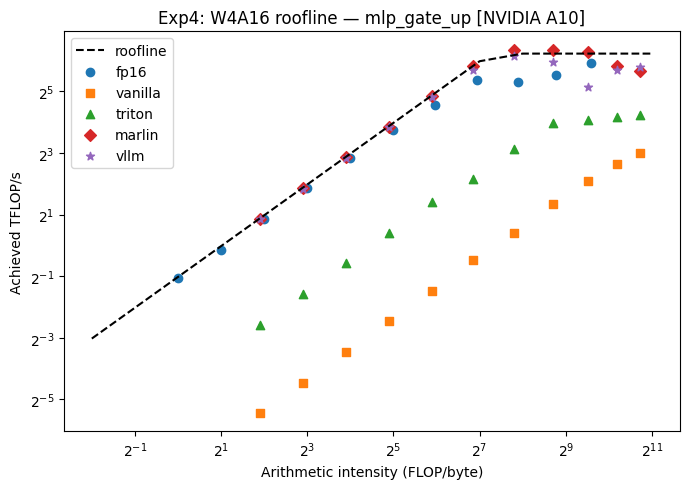

In [4]:
import json
import matplotlib.pyplot as plt

exp4 = json.load(open("results/exp4.json"))

def plot_roofline(results, mode="scatter", shape="mlp_gate_up"):
    peak_tflops = results["hardware"]["peak_tflops_fp16"]
    peak_bw     = results["hardware"]["peak_bw_gbps"]
    fig, ax = plt.subplots(figsize=(7, 5))
    xs = [2 ** i for i in range(-2, 12)]
    ax.plot(xs, [min(peak_tflops, peak_bw * x / 1e3) for x in xs], "k--", label="roofline")
    markers = {"fp16": "o", "vanilla": "s", "triton": "^", "marlin": "D", "vllm": "*"}
    colors  = {"fp16": "C0", "vanilla": "C1", "triton": "C2", "marlin": "C3", "vllm": "C4"}
    for kname in markers:
        pts = sorted(
            [(r["intensity"], r["tflops"]) for r in results["gemm_roofline"]
             if r["kernel"] == kname and r["shape"] == shape],
            key=lambda p: p[0],
        )
        if not pts: continue
        xs_k, ys_k = zip(*pts)
        if mode == "line":
            ax.plot(xs_k, ys_k, marker="o", markersize=4, color=colors[kname], label=kname)
        else:
            ax.scatter(xs_k, ys_k, marker=markers[kname], color=colors[kname], label=kname)
    ax.set_xscale("log", base=2)
    ax.set_yscale("log", base=2)
    ax.set_xlabel("Arithmetic intensity (FLOP/byte)")
    ax.set_ylabel("Achieved TFLOP/s")
    ax.set_title(f"Exp4: W4A16 roofline — {shape} [{results['hardware']['device']}]")
    ax.legend()
    plt.tight_layout()
    plt.show()

# mode="line" connects M-sweep points with colored lines instead of isolated dots
plot_roofline(exp4, mode="scatter")